# Сборный аналитический проект — анализ данных и выводы

## Цель
Выполнить комплексный анализ данных: очистка, исследование, расчёт метрик и формулирование выводов для бизнеса.

## Задачи
- подготовить данные (типы, пропуски, дубликаты)
- провести EDA и построить визуализации
- рассчитать ключевые показатели и сделать выводы
- описать ограничения и дальнейшие шаги

## Данные
Учебный набор данных (сборный проект). Конкретное описание датасета приведено в ноутбуке в разделе загрузки/описания данных.

## Инструменты
Python, pandas, numpy, matplotlib/seaborn

### Описание проекта

В интернет_магазине "Стримчик", который продаёт по всему миру компьютерные игры, нужно выявить определяющие успешность игры закономерности. Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.
Имеются данные до 2016 года.

In [1782]:
!pip install missingno -q

In [1783]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.figure_factory as ff
import plotly.graph_objects as go
import missingno as msno
from scipy import stats as st

### Шаг 1. Загрузка данных

In [1784]:
try:
    df = pd.read_csv('/datasets/games.csv')
except:
    df = pd.read_csv('C:/Users/Student/Desktop/dataset.csv')

In [1785]:
df.head(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


In [1786]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


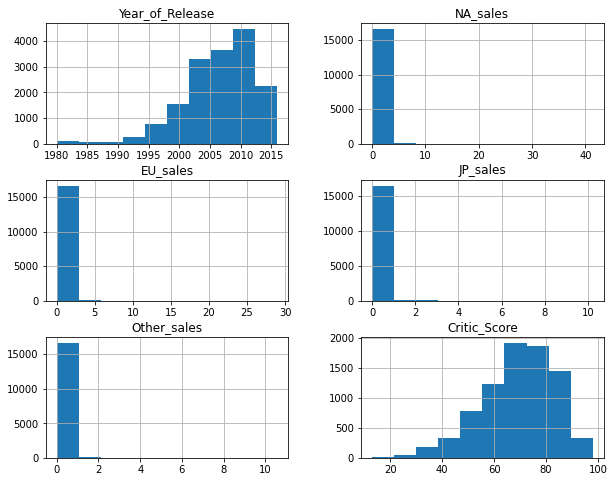

In [1787]:
df.hist(figsize=(10, 8))
plt.show()

#### Общая информация о датафреймах

 **Name** — название игры 
 
 **Platform** — платформа
 
 **Year_of_Release** — год выпуска
 
 **Genre** — жанр игры
 
 **NA_sales** — продажи в Северной Америке (миллионы проданных копий)
 
 **EU_sales** — продажи в Европе (миллионы проданных копий)
 
 **JP_sales** — продажи в Японии (миллионы проданных копий)
 
 **Other_sales** — продажи в других странах (миллионы проданных копий)
 
 **Critic_Score** — оценка критиков (максимум 100)
 
 **User_Score** — оценка пользователей (максимум 10)
 
 **Rating** — рейтинг от организации ESRB (англ. Entertainment Software Rating Board). Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию.
 
 Датафрейм имеет 16715 строк и 11 столбцов.

### Шаг 2. Предобработка данных

##### Заменим названия столбцов, приведем к нижнему регистру

In [1788]:
df = df.rename(
    columns={'Name': 'name', 'Platform': 'platform', 
                        'Year_of_Release': 'year_of_release', 
                        'Genre': 'genre', 'NA_sales': 'na_sales', 
                        'EU_sales': 'eu_sales', 'JP_sales': 'jp_sales', 
                        'Other_sales': 'other_sales', 'Critic_Score': 'critic_score',
                        'User_Score': 'user_score', 'Rating': 'rating', 
            }
)

In [1789]:
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


##### Преобразуем данные в нужные типы

In [1790]:
df['year_of_release'] = pd.to_numeric(df['year_of_release'], downcast='integer')
df['critic_score'] = pd.to_numeric(df['critic_score'], downcast='integer')
df['user_score'] = pd.to_numeric(df['user_score'], downcast='float', errors ='coerce')
df['user_score'] = df['user_score'].round(1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float32
 10  rating           9949 non-null   object 
dtypes: float32(1), float64(6), object(4)
memory usage: 1.3+ MB


In [1791]:
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


##### Обработка пропусков

Определение значимых и восстанавливаемых пропусков данных:

 **Возможно восстановить**
- year_of_release. В названиях могут присутствовать год. Для спортивных игр надо учитывать, что написаный год может означать год конца сезона. Пример FIFA 2004 это про сезон 2003/2004 года по футболу. Значит игру выпускают перед началом сезона, тоесть в 2003.
- rating. ESRB часто повторяет один и тот де тип оценки для одинаковых жанров. Восстановим их используя популярный ESRB рейтинг в жанре.

**Нетребующие восстановления**
- Строки 659 и 14244. Они будут удалены. 

**Невозможно восстановить**
- critic_score и user_score. В этих столбцах нельзя выявить средние или медианные закономерности по году или жанру. Каждая игра получается индивидуальной и оценка критиков, и пользователей - субъективное мнение об игре конкретного года, жанра, платформы, студии разработчика, издателя, рекламы и репутации о серии игр. Слишком много факторов необходимо учесть для восстановления данных.

Удаление строк 659 и 14244.

In [1792]:
df.drop([659, 14244],inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16713 non-null  object 
 2   year_of_release  16444 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float32
 10  rating           9949 non-null   object 
dtypes: float32(1), float64(6), object(4)
memory usage: 1.5+ MB


Восстановление и удаление значений по столбцу year_of_release. 
Для игр с годом в названии проанализируем жанр.

In [1793]:
nan_year_data = df[df['year_of_release'].isna()]
nan_year_data

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,NaN,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,PS2,NaN,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
456,LEGO Batman: The Videogame,Wii,NaN,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
609,Space Invaders,2600,NaN,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16373,PDC World Championship Darts 2008,PSP,NaN,Sports,0.01,0.00,0.00,0.00,43.0,NaN,E10+
16405,Freaky Flyers,GC,NaN,Racing,0.01,0.00,0.00,0.00,69.0,6.5,T
16448,Inversion,PC,NaN,Shooter,0.01,0.00,0.00,0.00,59.0,6.7,M
16458,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [1794]:
def fill_year(row):
    year = 0
    last_word = ''
    genre = row[3]
    for word in row[0].split():
        try:
            last_word = word
            year = int(word)
        except:
            continue
    if genre in ('Sports', 'Racing', 'Fighting'):
        if year > 2000 or last_word in ('2K6','2K8'):
            if genre == 'Sports':
                year -=1
            if last_word == '2K6':
                year = 2005
            elif last_word == '2K8':
                year = 2007
            if year < 2017 and np.isnan(row[2]):
                row[2] = year
    return row

df = df.apply(fill_year, axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16713 non-null  object 
 2   year_of_release  16462 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: float64(7), object(4)
memory usage: 1.5+ MB


Для аналитики не нужны игры без года создания, т.к. данные не могут быть актуальными на выбранный позднее период.

In [1795]:
df.drop(df[df['year_of_release'].isna()].index,inplace=True)
df['year_of_release'] = pd.to_numeric(df['year_of_release'], downcast='integer')
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16462 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16462 non-null  object 
 1   platform         16462 non-null  object 
 2   year_of_release  16462 non-null  int16  
 3   genre            16462 non-null  object 
 4   na_sales         16462 non-null  float64
 5   eu_sales         16462 non-null  float64
 6   jp_sales         16462 non-null  float64
 7   other_sales      16462 non-null  float64
 8   critic_score     7997 non-null   float64
 9   user_score       7473 non-null   float64
 10  rating           9781 non-null   object 
dtypes: float64(6), int16(1), object(4)
memory usage: 1.4+ MB


Восстановление рейтинга ESRB. Определение самой популярной оценки для жанра и составим словарь.

In [1796]:
genre_list = df['genre'].unique()
genre_dict = {}
for genre in genre_list:
    print('Популярные оценки для жанра ', genre)
    rating_value_counts = df[df['genre'] == genre]['rating'].value_counts()
    print(rating_value_counts)
    genre_dict[genre] = rating_value_counts.index[0]
    
genre_dict

Популярные оценки для жанра  Sports
E       1173
T        195
E10+     106
M         16
Name: rating, dtype: int64
Популярные оценки для жанра  Platform
E       354
E10+    141
T        63
M         3
Name: rating, dtype: int64
Популярные оценки для жанра  Racing
E       577
T       167
E10+     95
M        18
Name: rating, dtype: int64
Популярные оценки для жанра  Role-Playing
T       415
M       161
E10+    111
E        83
Name: rating, dtype: int64
Популярные оценки для жанра  Puzzle
E       284
E10+     42
T        10
Name: rating, dtype: int64
Популярные оценки для жанра  Misc
E       449
T       228
E10+    166
M        13
EC        5
K-A       1
Name: rating, dtype: int64
Популярные оценки для жанра  Shooter
M       553
T       340
E10+     56
E        47
Name: rating, dtype: int64
Популярные оценки для жанра  Simulation
E       321
T       186
E10+     47
M         5
Name: rating, dtype: int64
Популярные оценки для жанра  Action
T       670
M       596
E10+    468
E       410
A

{'Sports': 'E',
 'Platform': 'E',
 'Racing': 'E',
 'Role-Playing': 'T',
 'Puzzle': 'E',
 'Misc': 'E',
 'Shooter': 'M',
 'Simulation': 'E',
 'Action': 'T',
 'Fighting': 'T',
 'Adventure': 'E',
 'Strategy': 'T'}

In [1797]:
df['rating'] = df['rating'].fillna('No information')

df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16462 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16462 non-null  object 
 1   platform         16462 non-null  object 
 2   year_of_release  16462 non-null  int16  
 3   genre            16462 non-null  object 
 4   na_sales         16462 non-null  float64
 5   eu_sales         16462 non-null  float64
 6   jp_sales         16462 non-null  float64
 7   other_sales      16462 non-null  float64
 8   critic_score     7997 non-null   float64
 9   user_score       7473 non-null   float64
 10  rating           16462 non-null  object 
dtypes: float64(6), int16(1), object(4)
memory usage: 1.4+ MB


In [1798]:
df['rating'].value_counts()

No information    6681
E                 3933
T                 2905
M                 1536
E10+              1394
EC                   8
K-A                  3
AO                   1
RP                   1
Name: rating, dtype: int64

**Удаление дубликатов**

In [1799]:
df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16462 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16462 non-null  object 
 1   platform         16462 non-null  object 
 2   year_of_release  16462 non-null  int16  
 3   genre            16462 non-null  object 
 4   na_sales         16462 non-null  float64
 5   eu_sales         16462 non-null  float64
 6   jp_sales         16462 non-null  float64
 7   other_sales      16462 non-null  float64
 8   critic_score     7997 non-null   float64
 9   user_score       7473 non-null   float64
 10  rating           16462 non-null  object 
dtypes: float64(6), int16(1), object(4)
memory usage: 1.4+ MB


**Добавление столбца world_sales**

In [1800]:
df['world_sales'] = (df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales'])
df.head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,world_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,No information,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,No information,31.38
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,No information,30.26
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91
8,New Super Mario Bros. Wii,Wii,2009,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E,28.32
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,No information,28.31


##### Вывод по предобработке данных

Данные готовы к анализу. Было выполнено следующее.

1. Название столбцов было приведено к нижнему регистру
2. Восстановлены пропуски в строках.
3. Удалены строки без нужных данных.
4. Добавлен столбец суммарных продаж.

### Шаг 3. Исследовательский анализ данных

**Ответим на вопросы**
- Посмотрите, сколько игр выпускалось в разные годы. Важны ли данные за все периоды?
- Посмотрите, как менялись продажи по платформам. Выберите платформы с наибольшими суммарными продажами и постройте распределение по годам. За какой характерный срок появляются новые и исчезают старые платформы?
- Возьмите данные за соответствующий актуальный период. Актуальный период определите самостоятельно в результате исследования предыдущих вопросов. Основной фактор — эти данные помогут построить прогноз на 2017 год.
- Не учитывайте в работе данные за предыдущие годы.
- Какие платформы лидируют по продажам, растут или падают? Выберите несколько потенциально прибыльных платформ.
- Постройте график «ящик с усами» по глобальным продажам игр в разбивке по платформам. Опишите результат.
- Посмотрите, как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков. Постройте диаграмму рассеяния и посчитайте корреляцию между отзывами и продажами. Сформулируйте выводы.
- Соотнесите выводы с продажами игр на других платформах.
- Посмотрите на общее распределение игр по жанрам. Что можно сказать о самых прибыльных жанрах? Выделяются ли жанры с высокими и низкими продажами?

**Первый вопрос**
- Важны ли данные за все периоды?

In [1801]:
year_of_release_pivot_table = pd.pivot_table(df, index='year_of_release', values='name', aggfunc ='count')
year_of_release_pivot_table.columns = ['games_count']
year_of_release_pivot_table

,games_count
year_of_release,
1980,9
1981,46
1982,36
1983,17
1984,14
1985,14
1986,21
1987,16
1988,15


<AxesSubplot:xlabel='year_of_release'>

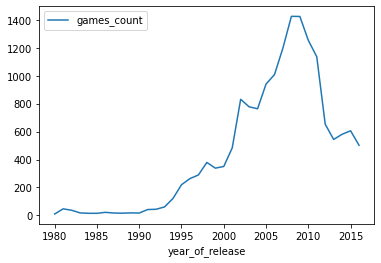

In [1802]:
year_of_release_pivot_table.plot()

**Ответ на 1 вопрос**

Данные по всем периодам не важны.

С 1980 по 1993 год было мало компаний и охват игроков был небольшим. 

С 2002 года выпустилось много игры, это видно по статистке и графику. Это значит, что в период с 1997 по 2002 появились игровые движки для создания игр.

В 2009 году произошел пик популярности создания игр и увеличилось распрастраненность игровых движков.

Спад игровой индустрии игр с 2012 по 2016 год обусловлен экономическим кризисом и требованиями к играм.

**2 вопрос**

-  За какой характерный срок появляются новые и исчезают старые платформы?

In [1803]:
platform_sales_pivot_table = pd.pivot_table(df, index=['platform'], values='world_sales', aggfunc='sum')
platform_sales_pivot_table = platform_sales_pivot_table.sort_values('world_sales', ascending=False)
platform_sales_pivot_table

,world_sales
platform,
PS2,1247.53
X360,961.30
PS3,931.34
Wii,891.18
DS,802.79
PS,727.58
PS4,314.14
GBA,312.88
PSP,289.69


In [1804]:
best_sales_platform = list(platform_sales_pivot_table.index[:6])
best_sales_platform

['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS']

In [1805]:
df.loc[15957, 'year_of_release'] = 2007

In [1806]:
for platform in best_sales_platform:
    print('Платформа', platform)
    platform_sales_pivot_table = pd.pivot_table(df.query('platform == @platform'), 
                                                index=['platform', 'year_of_release'],
                                                values='world_sales',
                                                aggfunc='sum')
    print(platform_sales_pivot_table)
    print()

Платформа PS2
                          world_sales
platform year_of_release             
PS2      2000                   39.17
         2001                  166.43
         2002                  205.78
         2003                  194.27
         2004                  212.13
         2005                  160.91
         2006                  106.46
         2007                   75.99
         2008                   53.90
         2009                   26.40
         2010                    5.64
         2011                    0.45

Платформа X360
                          world_sales
platform year_of_release             
X360     2005                    8.25
         2006                   51.63
         2007                   95.41
         2008                  135.26
         2009                  120.29
         2010                  170.03
         2011                  143.89
         2012                   99.74
         2013                   88.58
         2014       

In [1807]:
def top_plat(tbl):
    global top_platforms
    global top_sales
    top_platforms = tbl.pivot_table(index='platform', values='world_sales', aggfunc='sum').sort_values(by = 'world_sales', 
                                                                                                        ascending = False).head(6).reset_index()
    
    top_sales = tbl[tbl['platform'].isin(top_platforms['platform'])].pivot_table(index='year_of_release', values='world_sales', columns='platform', aggfunc='sum')
    
    plt.figure(figsize=(12,6))
    plt.title('Количество продаж популярных игровых платформ')
    plt.xlabel('Годы игровых релизов')
    plt.ylabel('Продажи')
    sns.lineplot(data= top_sales)
    plt.legend()
    plt.show()

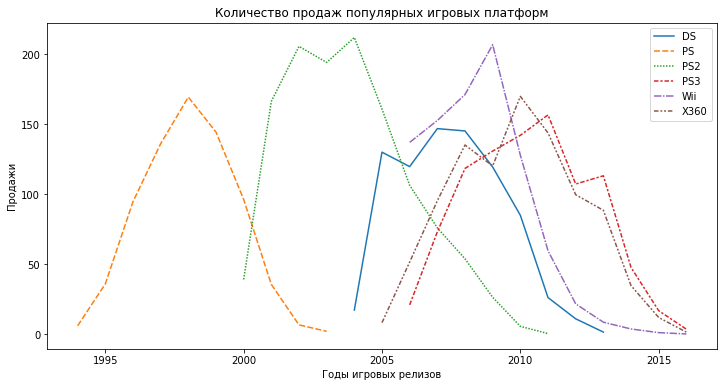

In [1808]:
top_plat(df)

In [1809]:
print('Платформа', 'ps4')
platform_sales_pivot_table = pd.pivot_table(df.query('platform == "PS4"'),
                                           index = ['platform', 'year_of_release'],
                                           values = 'world_sales', aggfunc = 'sum')
print(platform_sales_pivot_table)
print()

Платформа ps4
                          world_sales
platform year_of_release             
PS4      2013                   25.99
         2014                  100.00
         2015                  118.90
         2016                   69.25



**Ответ на вопрос 2**

Для платформ, которые пользуются популярностью, срок использования равен 8-12 лет. Можно проследить, как менялись поколения для приствок PlayStation:

- PS 1994-2003
- PS2 2000-2011
- PS3 2006-2016 
- PS4 2013-по сегодняшний день

Получается каждые 5-7 лет компания Sony выпускает новую платформу с лучшими техническими параметрами, а игры на предыдущей платформе еще существуют на рынке 3 года.

**3 вопрос**

 - Актуальный период определите самостоятельно в результате исследования предыдущих вопросов. Основной фактор — эти данные помогут построить прогноз на 2017 год.

Актуальным периодом по продажам считаю с 2013 по 2016 год.

1. Появление на рынке новой платформы PS4 говорит от том, что она просуществует 2-4 года и топ продаж для этой платформы ожидается на 2017 год.
2. После падения суммарных продаж с 2013 года появилась тенденция к росту продаж игр за счет их качества, а не количества.
3. Большинство студий разработчиков создают игры за 2-4 года, так что в 2017 попадут игры, разработка которых ведется с 2013 года.
4. Хорошие игры на рынке продаются в течении нескольких лет.

In [1810]:
actual_data_games_sales = df.query('year_of_release > 2012')
actual_data_games_sales.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2233 entries, 16 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             2233 non-null   object 
 1   platform         2233 non-null   object 
 2   year_of_release  2233 non-null   int16  
 3   genre            2233 non-null   object 
 4   na_sales         2233 non-null   float64
 5   eu_sales         2233 non-null   float64
 6   jp_sales         2233 non-null   float64
 7   other_sales      2233 non-null   float64
 8   critic_score     991 non-null    float64
 9   user_score       1192 non-null   float64
 10  rating           2233 non-null   object 
 11  world_sales      2233 non-null   float64
dtypes: float64(7), int16(1), object(4)
memory usage: 213.7+ KB


Сделав отсев по году, одновременно дали ответ на 4й вопрос.

In [1811]:
actual_data_games_sales.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,world_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,No information,14.63
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,No information,14.60
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62


**5 вопрос**

- Какие платформы лидируют по продажам, растут или падают? Выберите несколько потенциально прибыльных платформ.

Определим самые прибыльные платформы за актуальный период.

In [1812]:
best_sales_platform = pd.pivot_table(actual_data_games_sales, index=['platform','year_of_release'], 
                                     values='world_sales', aggfunc = 'sum')
best_sales_platform

/opt/conda/lib/python3.9/site-packages/IPython/core/displayhook.py:275: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


world_sales
platform year_of_release             
3DS      2013                   56.57
         2014                   43.76
         2015                   27.78
         2016                   15.14
DS       2013                    1.54
PC       2013                   12.38
         2014                   13.28
         2015                    8.52
         2016                    5.25
PS3      2013                  113.25
         2014                   47.76
         2015                   16.82
         2016                    3.60
PS4      2013                   25.99
         2014                  100.00
         2015                  118.90
         2016                   69.25
PSP      2013                    3.14
         2014                    0.24
         2015                    0.12
PSV      2013                   10.59
         2014                   11.90
         2015                    6.25
         2016                    4.25
Wii      2013                    8.59
         2014                    3.75
         2015                    1.14
         2016                    0.18
WiiU     2013                   21.65
         2014                   22.03
         2015                   16.35
         2016                    4.60
X360     2013                   88.58
         2014                   34.74
         2015                   11.96
         2016                    1.52
XOne     2013                   18.96
         2014                   54.07
         2015                   60.14
         2016                   26.15

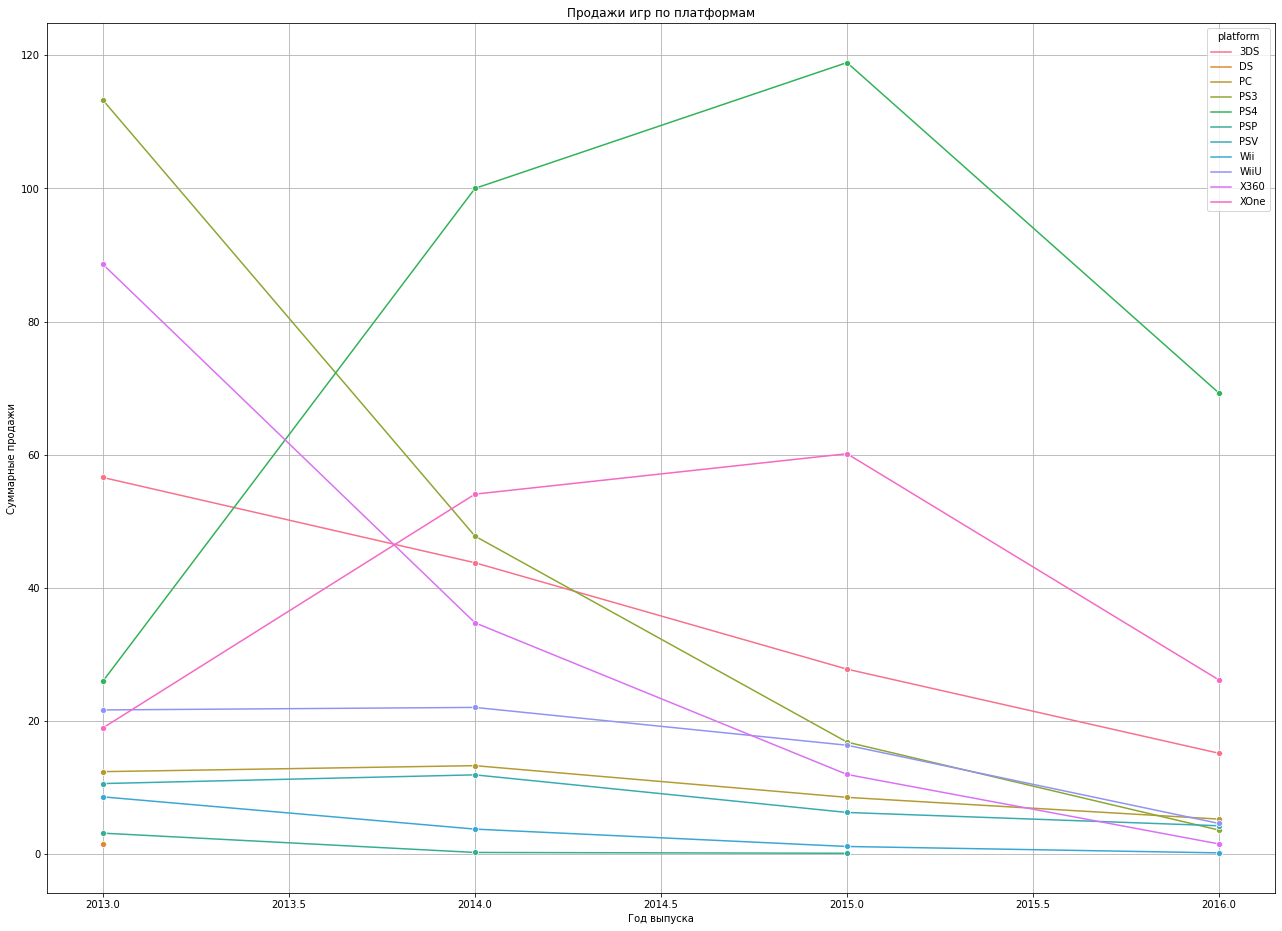

In [1813]:
best_sales_platform_reset = best_sales_platform.reset_index()

plt.figure(figsize=(22, 16))

sns.lineplot(data=best_sales_platform_reset, x='year_of_release', y='world_sales', hue='platform', marker='o')

plt.title('Продажи игр по платформам')
plt.xlabel('Год выпуска')
plt.ylabel('Суммарные продажи')
plt.grid()
plt.show()

Количество продаж по всем платформам падает к 2016 году.

In [1814]:
best_sales_platform = pd.pivot_table(actual_data_games_sales, index='platform', 
                                     values='world_sales', aggfunc = 'sum')
best_sales_platform.sort_values('world_sales', ascending=False)

,world_sales
platform,
PS4,314.14
PS3,181.43
XOne,159.32
3DS,143.25
X360,136.80
WiiU,64.63
PC,39.43
PSV,32.99
Wii,13.66


**Ответ на 5 вопрос**

Топ 5 платформ по миру: PS4, PS3, XOne, X360 и 3DS. Их суммарный доход за 3 года около 1 миллиарда долларов.

Количество продаж по всем платформам падает к 2016 году. Потенциально прибыльне платформы можно считать: PS4, XOne, 3DS, WiiU и PSV.

**6 вопрос**

- Постройте график «ящик с усами» по глобальным продажам игр в разбивке по платформам. Опишите результат.

In [1815]:
list_of_top_6 = ['PS4','XOne','WiiU','3DS', 'PSV']
top_6 = df[df['platform'].isin(['PS4','XOne','WiiU','3DS', 'PSV'])]

In [1816]:
top_6.describe()

,year_of_release,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,world_sales
count,1727.000000,1727.000000,1727.000000,1727.000000,1727.000000,796.000000,852.00000,1727.000000
mean,2014.141285,0.194024,0.169166,0.087881,0.051112,70.967337,6.83662,0.502183
std,1.548656,0.506066,0.492371,0.306206,0.144302,12.777100,1.43921,1.232736
min,2011.000000,0.000000,0.000000,0.000000,0.000000,19.000000,1.50000,0.010000
25%,2013.000000,0.000000,0.000000,0.000000,0.000000,64.000000,6.10000,0.040000
50%,2014.000000,0.030000,0.020000,0.020000,0.010000,73.000000,7.10000,0.120000
75%,2015.000000,0.160000,0.120000,0.060000,0.040000,80.000000,7.90000,0.390000
max,2016.000000,6.030000,6.310000,4.390000,2.380000,97.000000,9.30000,14.630000


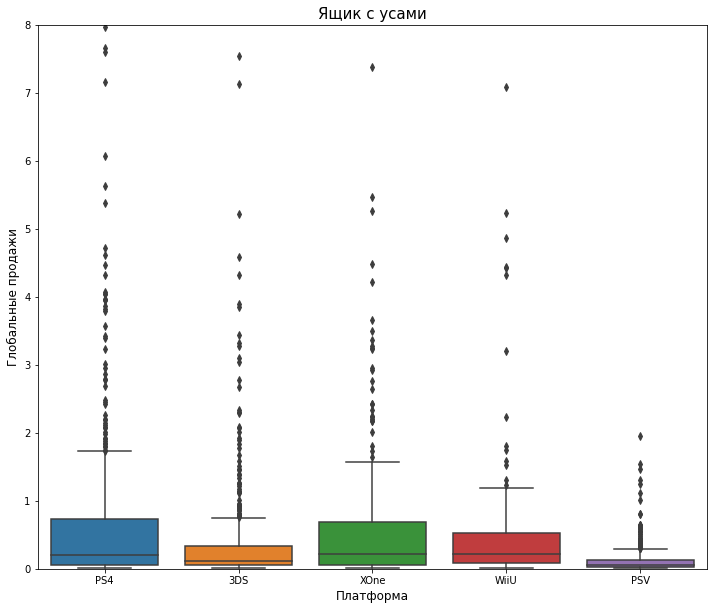

In [1817]:
plt.figure(figsize=(12,10))
sns.boxplot(data=top_6, x='platform', y='world_sales')
plt.title('Ящик с усами', fontsize=15)
plt.xlabel('Платформа', fontsize=12)
plt.ylabel('Глобальные продажи',fontsize=12)
plt.ylim(0, 8)
plt.show()

**Ответ на вопрос 6**

Разница в продажах отличается. Имеются очень популярные игры, которые продаются годами и дают много прибыли, таковых единицы. И много игр, которые не смогли преодолеть порог в 400 тыс. долларов за выбранный период.

Период 2013-2016 год

- Средняя выручка на игру по миру: 488 тыс. дол. 3/4 игр заработали до 400 тыс. Рекорд 21 млн.
- Средняя выручка на игру по платформе PS4: 801 тыс. 3/4 игр заработали до 730 тыс. Рекорд 14,6 млн.
- Средняя выручка на игру по платформе PS3: 526 тыс. 3/4 игр заработали до 510 тыс. Рекорд 21 млн.
- Средняя выручка на игру по платформе XOne: 645 тыс. 3/4 игр заработали до 685 тыс. Рекорд 7,4 млн.
- Средняя выручка на игру по платформе X360: 735 тыс. 3/4 игр заработали до 795 тыс. Рекорд 16,3 млн.
- Средняя выручка на игру по платформе 3DS: 472 тыс. 3/4 игр заработали до 280 тыс. Рекорд 14,6 млн.

Для PS4, PS3 и 3DS видна положительная тенденция к росту продаж. Средняя больше 3го квантиля, это значит на эти платформы делаются более популярные и продаваемые игры, чем на XOne и X360.

**7 вопрос**

- Посмотрите, как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков. Постройте диаграмму рассеяния и посчитайте корреляцию между отзывами и продажами. Сформулируйте выводы.

In [1818]:
PS4_sales_crit_and_user_ratings = PS4_actual_data_games_sales.loc[:,['world_sales', 'critic_score', 'user_score']]
PS4_sales_crit_and_user_ratings.head()

,world_sales,critic_score,user_score
31,14.63,NaN,NaN
42,12.62,97.0,8.3
77,8.58,82.0,4.3
87,7.98,NaN,NaN
92,7.66,83.0,5.7


In [1819]:
PS4_sales_crit_and_user_ratings.corr()

,world_sales,critic_score,user_score
world_sales,1.000000,0.406568,-0.031957
critic_score,0.406568,1.000000,0.557654
user_score,-0.031957,0.557654,1.000000


array([[<AxesSubplot:xlabel='world_sales', ylabel='world_sales'>,
        <AxesSubplot:xlabel='critic_score', ylabel='world_sales'>,
        <AxesSubplot:xlabel='user_score', ylabel='world_sales'>],
       [<AxesSubplot:xlabel='world_sales', ylabel='critic_score'>,
        <AxesSubplot:xlabel='critic_score', ylabel='critic_score'>,
        <AxesSubplot:xlabel='user_score', ylabel='critic_score'>],
       [<AxesSubplot:xlabel='world_sales', ylabel='user_score'>,
        <AxesSubplot:xlabel='critic_score', ylabel='user_score'>,
        <AxesSubplot:xlabel='user_score', ylabel='user_score'>]],
      dtype=object)

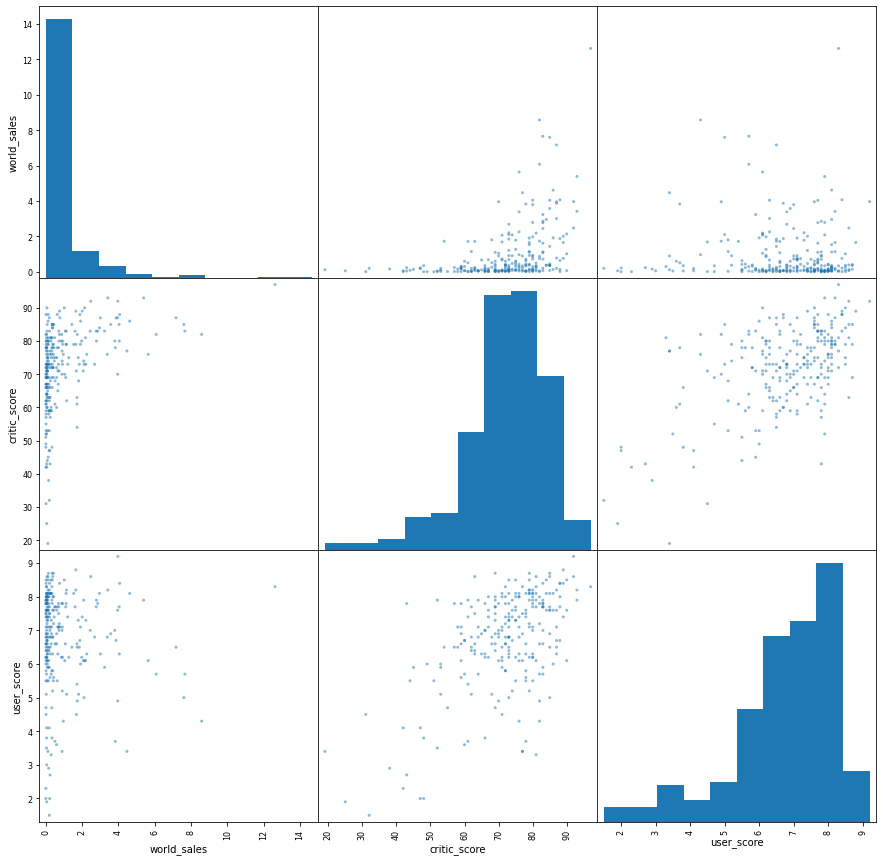

In [1820]:
pd.plotting.scatter_matrix(PS4_sales_crit_and_user_ratings, figsize=(15, 15))

**Ответ на вопрос 7**

Для платформы PS4 важными критерием является качество игры. Поэтому есть прямая корреляция между прибылью и рейтингом критиков. Обратная корреляция по игрокам не носит сильного смысла.

Важно заметить, что на мнение игроков влияет рейтинг. То есть, чем выше ценит игру критик, тем выше оценит ее игрок.

**Вопрос 8**

- Соотнесите выводы с продажами игр на других платформах.

In [1821]:
PS3_sales_crit_and_user_ratings = PS3_actual_data_games_sales.loc[:,['world_sales', 'critic_score', 'user_score']]
PS3_sales_crit_and_user_ratings.head()

,world_sales,critic_score,user_score
16,21.05,97.0,8.2
69,9.36,71.0,2.6
126,6.46,86.0,4.3
149,5.86,95.0,9.1
180,5.27,NaN,NaN


In [1822]:
PS3_sales_crit_and_user_ratings.corr()

,world_sales,critic_score,user_score
world_sales,1.000000,0.334285,0.002394
critic_score,0.334285,1.000000,0.599920
user_score,0.002394,0.599920,1.000000


array([[<AxesSubplot:xlabel='world_sales', ylabel='world_sales'>,
        <AxesSubplot:xlabel='critic_score', ylabel='world_sales'>,
        <AxesSubplot:xlabel='user_score', ylabel='world_sales'>],
       [<AxesSubplot:xlabel='world_sales', ylabel='critic_score'>,
        <AxesSubplot:xlabel='critic_score', ylabel='critic_score'>,
        <AxesSubplot:xlabel='user_score', ylabel='critic_score'>],
       [<AxesSubplot:xlabel='world_sales', ylabel='user_score'>,
        <AxesSubplot:xlabel='critic_score', ylabel='user_score'>,
        <AxesSubplot:xlabel='user_score', ylabel='user_score'>]],
      dtype=object)

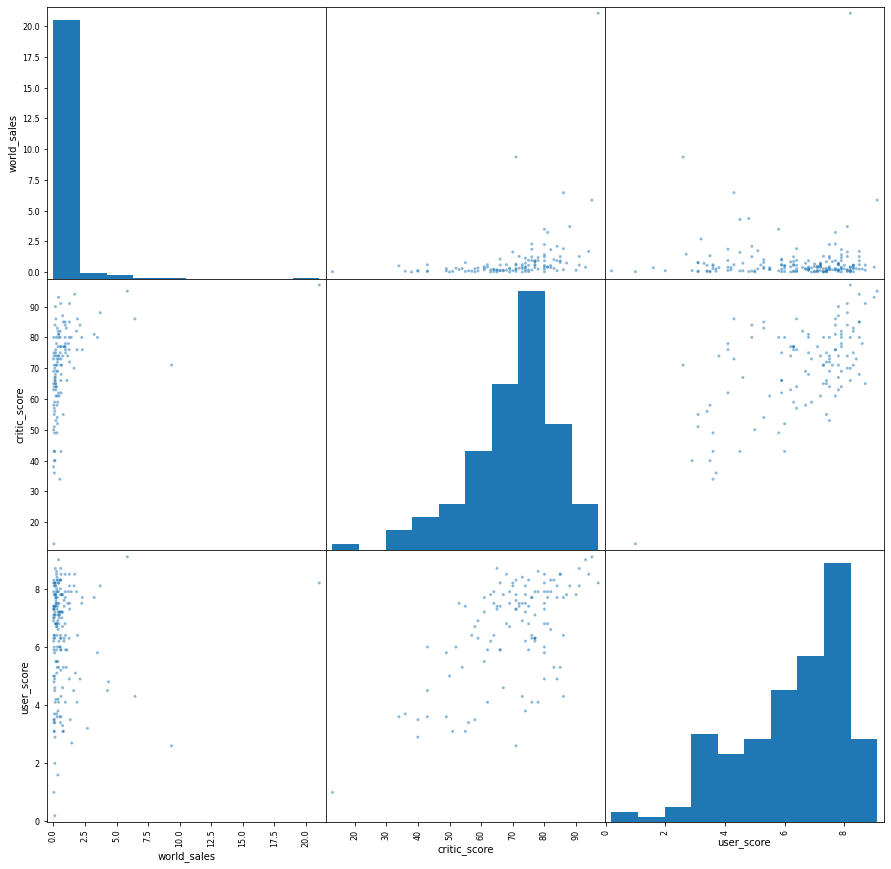

In [1823]:
pd.plotting.scatter_matrix(PS3_sales_crit_and_user_ratings, figsize=(15, 15))

In [1824]:
XOne_sales_crit_and_user_ratings = XOne_actual_data_games_sales.loc[:,['world_sales', 'critic_score', 'user_score']]
XOne_sales_crit_and_user_ratings.head()

,world_sales,critic_score,user_score
99,7.39,NaN,NaN
165,5.47,97.0,7.9
179,5.26,81.0,5.4
242,4.49,84.0,6.4
270,4.22,88.0,6.2


In [1825]:
XOne_sales_crit_and_user_ratings.corr()

,world_sales,critic_score,user_score
world_sales,1.000000,0.416998,-0.068925
critic_score,0.416998,1.000000,0.472462
user_score,-0.068925,0.472462,1.000000


array([[<AxesSubplot:xlabel='world_sales', ylabel='world_sales'>,
        <AxesSubplot:xlabel='critic_score', ylabel='world_sales'>,
        <AxesSubplot:xlabel='user_score', ylabel='world_sales'>],
       [<AxesSubplot:xlabel='world_sales', ylabel='critic_score'>,
        <AxesSubplot:xlabel='critic_score', ylabel='critic_score'>,
        <AxesSubplot:xlabel='user_score', ylabel='critic_score'>],
       [<AxesSubplot:xlabel='world_sales', ylabel='user_score'>,
        <AxesSubplot:xlabel='critic_score', ylabel='user_score'>,
        <AxesSubplot:xlabel='user_score', ylabel='user_score'>]],
      dtype=object)

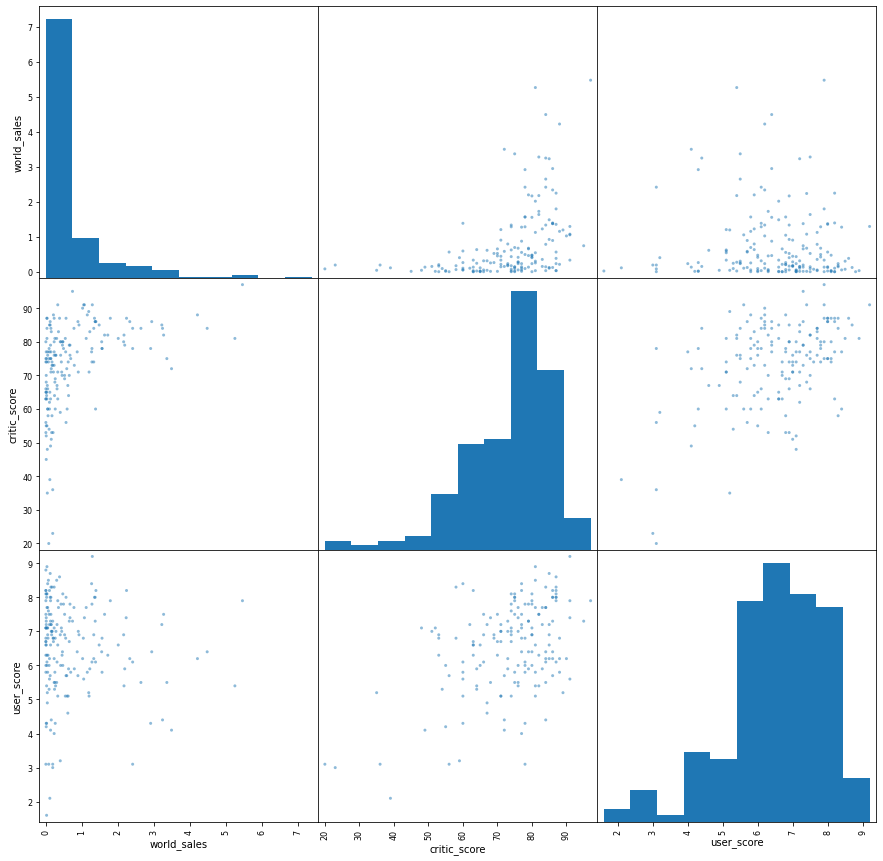

In [1826]:
pd.plotting.scatter_matrix(XOne_sales_crit_and_user_ratings, figsize=(15, 15))

In [1827]:
X360_sales_crit_and_user_ratings = X360_actual_data_games_sales.loc[:,['world_sales', 'critic_score', 'user_score']]
X360_sales_crit_and_user_ratings.head()

,world_sales,critic_score,user_score
23,16.27,97.0,8.1
60,10.24,73.0,2.6
72,9.18,NaN,NaN
263,4.28,NaN,4.9
271,4.22,84.0,4.2


In [1828]:
X360_sales_crit_and_user_ratings.corr()

,world_sales,critic_score,user_score
world_sales,1.000000,0.350345,-0.011742
critic_score,0.350345,1.000000,0.520946
user_score,-0.011742,0.520946,1.000000


array([[<AxesSubplot:xlabel='world_sales', ylabel='world_sales'>,
        <AxesSubplot:xlabel='critic_score', ylabel='world_sales'>,
        <AxesSubplot:xlabel='user_score', ylabel='world_sales'>],
       [<AxesSubplot:xlabel='world_sales', ylabel='critic_score'>,
        <AxesSubplot:xlabel='critic_score', ylabel='critic_score'>,
        <AxesSubplot:xlabel='user_score', ylabel='critic_score'>],
       [<AxesSubplot:xlabel='world_sales', ylabel='user_score'>,
        <AxesSubplot:xlabel='critic_score', ylabel='user_score'>,
        <AxesSubplot:xlabel='user_score', ylabel='user_score'>]],
      dtype=object)

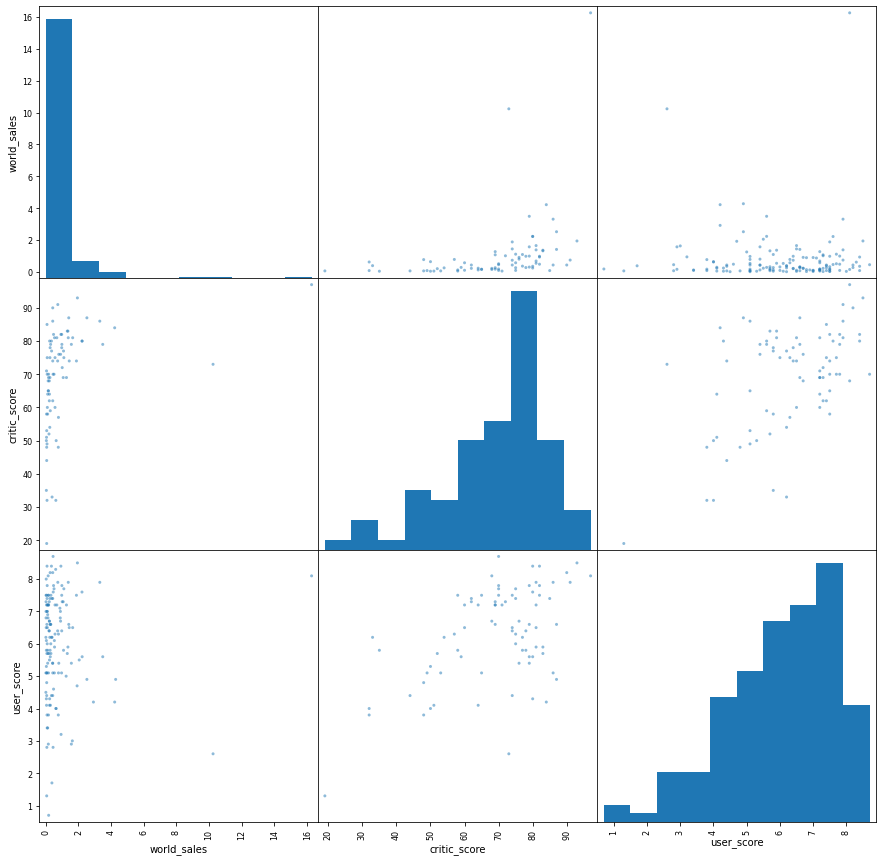

In [1829]:
pd.plotting.scatter_matrix(X360_sales_crit_and_user_ratings, figsize=(15, 15))

In [1830]:
_3DS_sales_crit_and_user_ratings = _3DS_actual_data_games_sales.loc[:,['world_sales', 'critic_score', 'user_score']]
_3DS_sales_crit_and_user_ratings.head()

,world_sales,critic_score,user_score
33,14.60,NaN,NaN
47,11.68,NaN,NaN
96,7.55,NaN,NaN
108,7.14,NaN,NaN
184,5.22,NaN,NaN


In [1831]:
_3DS_sales_crit_and_user_ratings.corr()

,world_sales,critic_score,user_score
world_sales,1.000000,0.357057,0.241504
critic_score,0.357057,1.000000,0.769536
user_score,0.241504,0.769536,1.000000


array([[<AxesSubplot:xlabel='world_sales', ylabel='world_sales'>,
        <AxesSubplot:xlabel='critic_score', ylabel='world_sales'>,
        <AxesSubplot:xlabel='user_score', ylabel='world_sales'>],
       [<AxesSubplot:xlabel='world_sales', ylabel='critic_score'>,
        <AxesSubplot:xlabel='critic_score', ylabel='critic_score'>,
        <AxesSubplot:xlabel='user_score', ylabel='critic_score'>],
       [<AxesSubplot:xlabel='world_sales', ylabel='user_score'>,
        <AxesSubplot:xlabel='critic_score', ylabel='user_score'>,
        <AxesSubplot:xlabel='user_score', ylabel='user_score'>]],
      dtype=object)

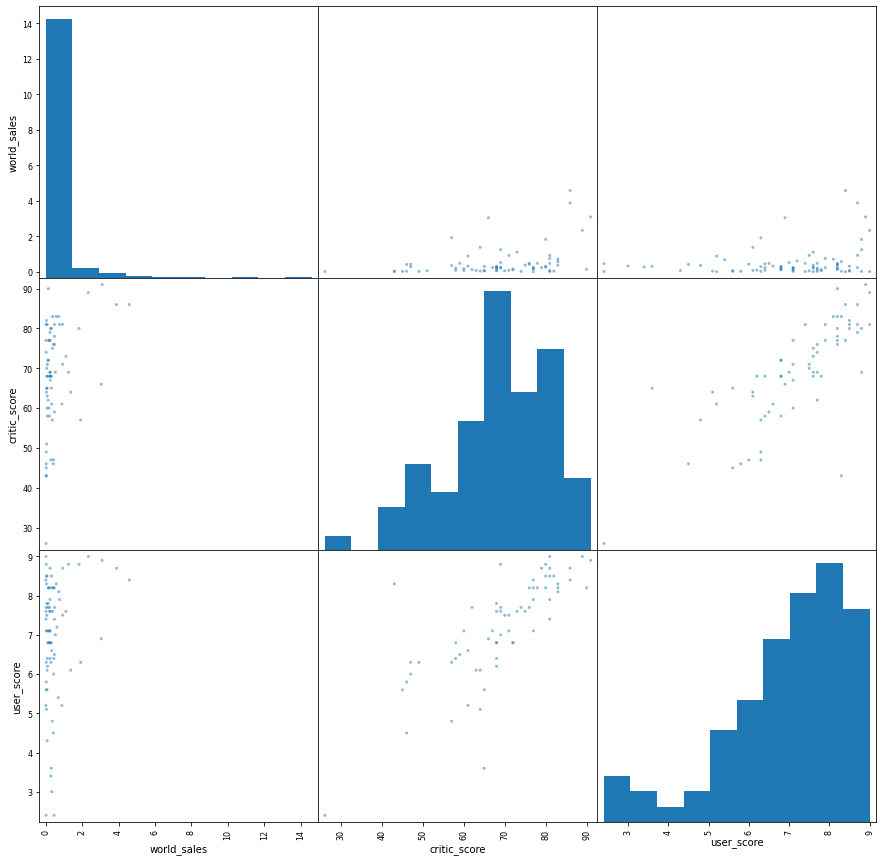

In [1832]:
pd.plotting.scatter_matrix(_3DS_sales_crit_and_user_ratings, figsize=(15, 15))

**Ответ на вопрос 8**

Платформы PS3, XOne и X360 имеют похожие связи, как и у PS4. 

Выделяется 3DS, чьи продажи зависят напрямую, хоть и не сильно от рейтинга игроков. Возможно здесь идет лучше работа по составлению рейтинга для игр и системы отзывов для игроков. А может игры в целом очень популярные и интересные и их не очень много, как у других платформ.

**9 вопрос**

- Что можно сказать о самых прибыльных жанрах? Выделяются ли жанры с высокими и низкими продажами?

In [1833]:
def genre(ind, value, func, label):
    genre_tbl = df.pivot_table(index=ind, values=value, aggfunc=func).sort_values(by ='world_sales', ascending = False).reset_index()
    plt.figure(figsize=(12,6))
    plt.title('Распределение игр по жанрам ',fontsize=15)
    sns.barplot(data=genre_tbl, x=ind, y=value)
    plt.xlabel('Жанры игр',fontsize=12)
    plt.ylabel(label,fontsize=12)
    plt.show()

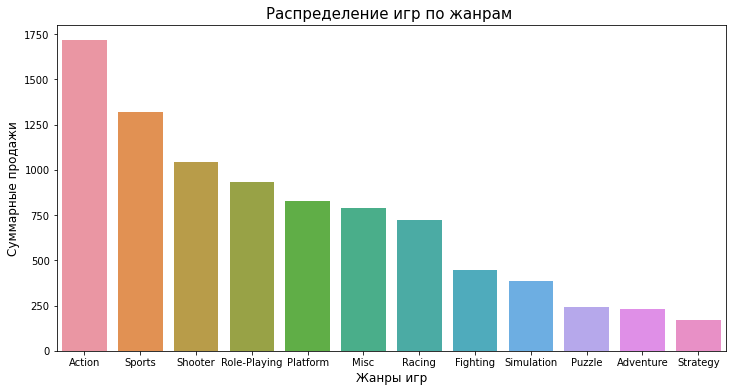

In [1834]:
genre('genre', 'world_sales', 'sum', 'Суммарные продажи')

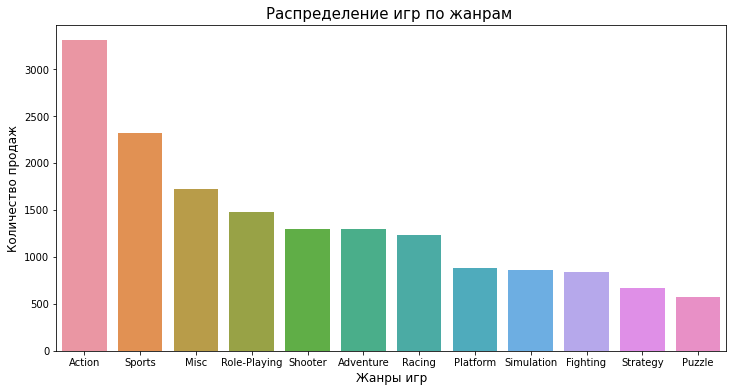

In [1835]:
genre('genre', 'world_sales', 'count', 'Количество продаж')

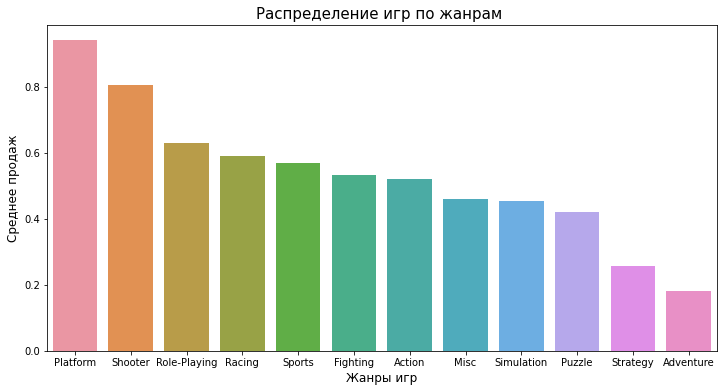

In [1836]:
genre('genre', 'world_sales', 'mean', 'Среднее продаж')

In [1837]:
genre_pivot_table = pd.pivot_table(df, index='genre', values='world_sales', aggfunc=['sum', 'count', 'mean']).reset_index()
genre_pivot_table.columns = ['genre', 'sum', 'count', 'mean']
genre_pivot_table.sort_values(by = 'mean', ascending=False)

,genre,sum,count,mean
4,Platform,825.55,878,0.940262
8,Shooter,1041.36,1296,0.803519
7,Role-Playing,931.08,1481,0.628683
6,Racing,724.80,1229,0.589748
10,Sports,1320.95,2320,0.569375
2,Fighting,445.66,838,0.531814
0,Action,1716.52,3307,0.519057
3,Misc,790.29,1721,0.459204
9,Simulation,387.96,857,0.452695
5,Puzzle,239.89,569,0.421599


- Больше всего суммарных продаж у жанра action, меньше всего puzzle
- Самое большое количество продаж у жанра action, меньше всего puzzle
- Среднее по продажам больше всего у жанра platform, меньше всех у adventure

**Ответ на 9 вопрос**

Самыми прибыльными жанрами можно считать экшен(Action), шутеры(Shooter), спортивные игры (Sports) и ролевые игры (Role-Playing).

Популярность экшена обусловлена историей создания игр и желания людей проверить свои навыки ловкости и реакции. Очень похожий на него тип жанра Misc.

Популярность шутеров, спортивых игр и ролевых игр обусловлена тем, что в большинстве из них играют несколько игроков одновременно. Так получаются соревнования формата 1х1, 2х2, 3х3, 5х5 и т.д.

Ролевые игры затягивают игроков своей сложностью к прохождению игры и соответсвенно в нее играют часто и даже перепроходят много раз, что увеличивает интерес к будущим дополнениям или повышают вероятность рассказа об этой игре друзьям.

На период 2013-2016 год не пользуются популярностью приключения (Adventure), симуляторы(Simulation) стратегии реального времени или пошаговые (Strategy) и головоломки (Puzzle).

Головоломки были популярны с 80х годов, но сейчас становится все меньше ценителей этого жанра. Текущее поколение хочет захватывающих действий. Приключение, хоть и появилось позже, оно имеет похожую тенденцию.

Симуляторы - это повторение реальной жизни или аспектов реальной жизни сейчас, в прошлом или в будущем. Этот жанр на любителя делать так, как ему хочется.

Стратегии редко когда поднимаются в рейтингах по продажам в ввиду еще большей трудности и иногда неторопливости процесса.

##### Вывод по исследовательскому анализу данных

Были даны ответы на все поставленые вопросы и рассуждения подкреплены обоснованиями.

Обобщенный вывод на 2017 год ожидается подъем продаж по PS4, XOne и 3DS, так как уже многие студии-разработчики нашли применения своих техологий на этих платформах и хотят попасть на все рынки.

### Шаг 3. Составьте портрет пользователя каждого региона

Определите для пользователя каждого региона (NA, EU, JP):

- Самые популярные платформы (топ-5). Опишите различия в долях продаж.
- Самые популярные жанры (топ-5). Поясните разницу.
- Влияет ли рейтинг ESRB на продажи в отдельном регионе?

Начнем с подготовки данных.

In [1838]:
na_actual_data_games_sales = actual_data_games_sales.query('na_sales > 0')
na_actual_data_games_sales.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1309 entries, 16 to 16672
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             1309 non-null   object 
 1   platform         1309 non-null   object 
 2   year_of_release  1309 non-null   int16  
 3   genre            1309 non-null   object 
 4   na_sales         1309 non-null   float64
 5   eu_sales         1309 non-null   float64
 6   jp_sales         1309 non-null   float64
 7   other_sales      1309 non-null   float64
 8   critic_score     809 non-null    float64
 9   user_score       974 non-null    float64
 10  rating           1309 non-null   object 
 11  world_sales      1309 non-null   float64
dtypes: float64(7), int16(1), object(4)
memory usage: 125.3+ KB


In [1839]:
eu_actual_data_games_sales = actual_data_games_sales.query('eu_sales > 0')
eu_actual_data_games_sales.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1422 entries, 16 to 16692
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             1422 non-null   object 
 1   platform         1422 non-null   object 
 2   year_of_release  1422 non-null   int16  
 3   genre            1422 non-null   object 
 4   na_sales         1422 non-null   float64
 5   eu_sales         1422 non-null   float64
 6   jp_sales         1422 non-null   float64
 7   other_sales      1422 non-null   float64
 8   critic_score     872 non-null    float64
 9   user_score       1047 non-null   float64
 10  rating           1422 non-null   object 
 11  world_sales      1422 non-null   float64
dtypes: float64(7), int16(1), object(4)
memory usage: 136.1+ KB


In [1840]:
jp_actual_data_games_sales = actual_data_games_sales.query('jp_sales > 0')
jp_actual_data_games_sales.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1187 entries, 16 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             1187 non-null   object 
 1   platform         1187 non-null   object 
 2   year_of_release  1187 non-null   int16  
 3   genre            1187 non-null   object 
 4   na_sales         1187 non-null   float64
 5   eu_sales         1187 non-null   float64
 6   jp_sales         1187 non-null   float64
 7   other_sales      1187 non-null   float64
 8   critic_score     410 non-null    float64
 9   user_score       462 non-null    float64
 10  rating           1187 non-null   object 
 11  world_sales      1187 non-null   float64
dtypes: float64(7), int16(1), object(4)
memory usage: 113.6+ KB


Найдем по каждому региону популярную платформу.

In [1841]:
na_platform_pivot_table = pd.pivot_table(na_actual_data_games_sales, index='platform', values='na_sales',
                                        aggfunc='sum').sort_values('na_sales', ascending=False)
na_platform_pivot_table

,na_sales
platform,
PS4,108.74
XOne,93.12
X360,81.66
PS3,63.50
3DS,38.20
WiiU,29.21
PC,11.11
Wii,6.56
PSV,5.04


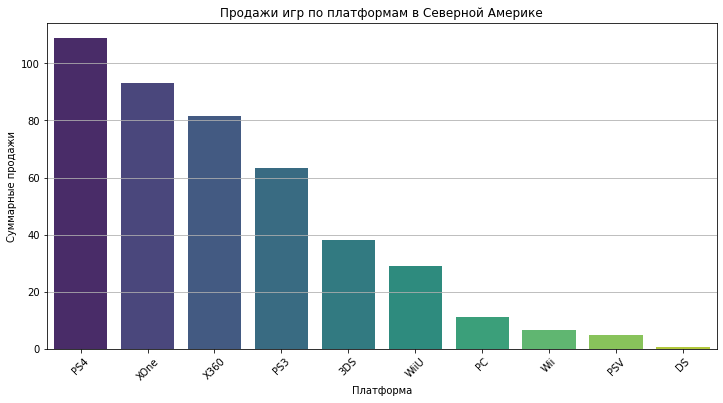

In [1842]:
na_platform_pivot_table_reset = na_platform_pivot_table.reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(data=na_platform_pivot_table_reset, x='platform', y='na_sales', palette='viridis')

plt.title('Продажи игр по платформам в Северной Америке')
plt.xlabel('Платформа')
plt.ylabel('Суммарные продажи')
plt.xticks(rotation=45) 
plt.grid(axis='y')
plt.show()

In [1843]:
eu_platform_pivot_table = pd.pivot_table(eu_actual_data_games_sales, index='platform', values='eu_sales',
                                        aggfunc='sum').sort_values('eu_sales', ascending=False)
eu_platform_pivot_table

,eu_sales
platform,
PS4,141.09
PS3,67.81
XOne,51.59
X360,42.52
3DS,30.96
PC,25.36
WiiU,19.85
PSV,6.10
Wii,5.93


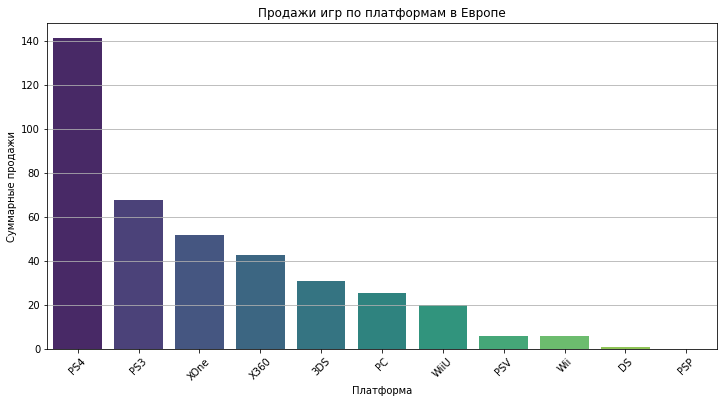

In [1844]:
eu_platform_pivot_table_reset = eu_platform_pivot_table.reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(data=eu_platform_pivot_table_reset, x='platform', y='eu_sales', palette='viridis')

plt.title('Продажи игр по платформам в Европе')
plt.xlabel('Платформа')
plt.ylabel('Суммарные продажи')
plt.xticks(rotation=45) 
plt.grid(axis='y')
plt.show()

In [1845]:
jp_platform_pivot_table = pd.pivot_table(jp_actual_data_games_sales, index='platform', values='jp_sales',
                                        aggfunc='sum').sort_values('jp_sales', ascending=False)
jp_platform_pivot_table

,jp_sales
platform,
3DS,67.81
PS3,23.35
PSV,18.59
PS4,15.96
WiiU,10.88
PSP,3.29
X360,0.51
XOne,0.34
Wii,0.05


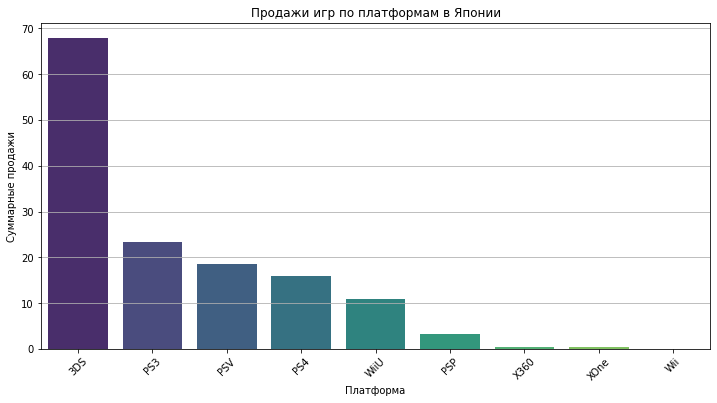

In [1846]:
jp_platform_pivot_table_reset = jp_platform_pivot_table.reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(data=jp_platform_pivot_table_reset, x='platform', y='jp_sales', palette='viridis')

plt.title('Продажи игр по платформам в Японии')
plt.xlabel('Платформа')
plt.ylabel('Суммарные продажи')
plt.xticks(rotation=45) 
plt.grid(axis='y')
plt.show()

Рейтинг платформ:
1. Топ 5 по Северной Америке: PS4, XOne, X360, PS3 и 3DS
2. Топ 5 по Европейскому региону: PS4, PS3, XOne, X360 и 3DS
3. Топ 5 по Японии: 3DS, PS3, PSV, PS4 и WiiU

Различия по популярности платформ в первую очередь зависят от влияния фирмы. Как результат во всех рейтингах есть продукция компании Sony. 

Во-вторых - местоположение компании.
Популярность XOne и X360 в Америке обусловлена крупным игроком на рынке в регионе - компания Microsoft.
В Японии похожее положение занимает компания Nintendo c двумя продуктами 3DS и WiiU. 
Европейский рынок смотрит на общую популярность платформы, так как как нет крупных компаний по разработке платформ.

На Американском рынке по продажам соревнуются PS4 и XOne. Это вечные конкуренты и компания Microsoft не хочет отставать по продажам в своем регионе.
В Европе нет такой сильной конкуренции - люди выбирают лучший и популярный продукт PS4.
В Японии высокая конкуренция Nintendo и Sony за пользователей. Как видно у первой компании есть успехи в родном регионе. Но плохие показатели за его пределами. В целом продажи меньше, так как в этом регионе меньше игроков.

Найдем по каждому региону популярный жанр.

In [1847]:
na_genre_pivot_table = pd.pivot_table(na_actual_data_games_sales, index='genre', values='na_sales',
                                        aggfunc='sum').sort_values('na_sales', ascending=False)
na_genre_pivot_table

,na_sales
genre,
Action,126.05
Shooter,109.74
Sports,65.27
Role-Playing,46.40
Misc,27.49
Platform,18.14
Fighting,15.55
Racing,12.96
Adventure,7.14


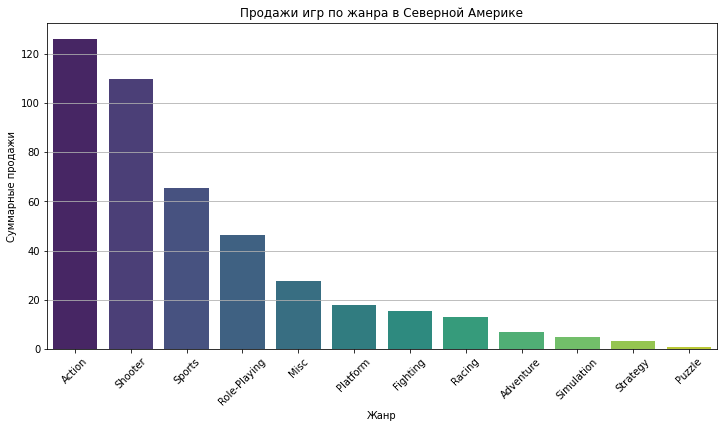

In [1848]:
na_genre_pivot_table_reset = na_genre_pivot_table.reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(data=na_genre_pivot_table_reset, x='genre', y='na_sales', palette='viridis')

plt.title('Продажи игр по жанра в Северной Америке')
plt.xlabel('Жанр')
plt.ylabel('Суммарные продажи')
plt.xticks(rotation=45) 
plt.grid(axis='y')
plt.show()

In [1849]:
eu_genre_pivot_table = pd.pivot_table(eu_actual_data_games_sales, index='genre', values='eu_sales',
                                        aggfunc='sum').sort_values('eu_sales', ascending=False)
eu_genre_pivot_table

,eu_sales
genre,
Action,118.13
Shooter,87.86
Sports,60.52
Role-Playing,36.97
Racing,20.19
Misc,20.04
Platform,15.58
Simulation,10.92
Fighting,8.55


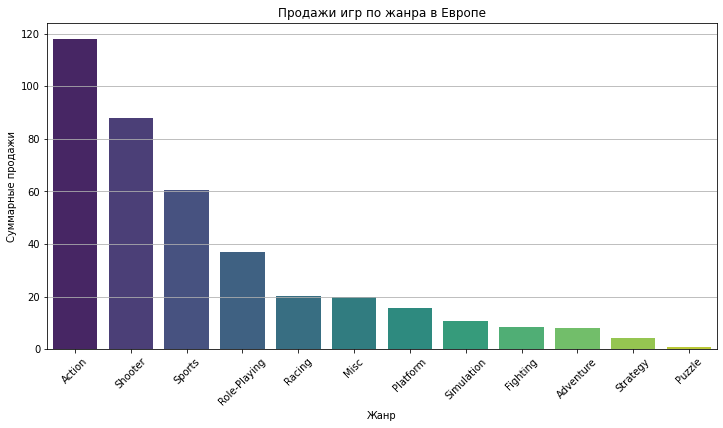

In [1850]:
eu_genre_pivot_table_reset = eu_genre_pivot_table.reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(data=eu_genre_pivot_table_reset, x='genre', y='eu_sales', palette='viridis')

plt.title('Продажи игр по жанра в Европе')
plt.xlabel('Жанр')
plt.ylabel('Суммарные продажи')
plt.xticks(rotation=45) 
plt.grid(axis='y')
plt.show()

In [1851]:
jp_genre_pivot_table = pd.pivot_table(jp_actual_data_games_sales, index='genre', values='jp_sales',
                                        aggfunc='sum').sort_values('jp_sales', ascending=False)
jp_genre_pivot_table

,jp_sales
genre,
Role-Playing,51.04
Action,40.49
Misc,9.20
Fighting,7.65
Shooter,6.61
Adventure,5.82
Sports,5.41
Platform,4.79
Simulation,4.52


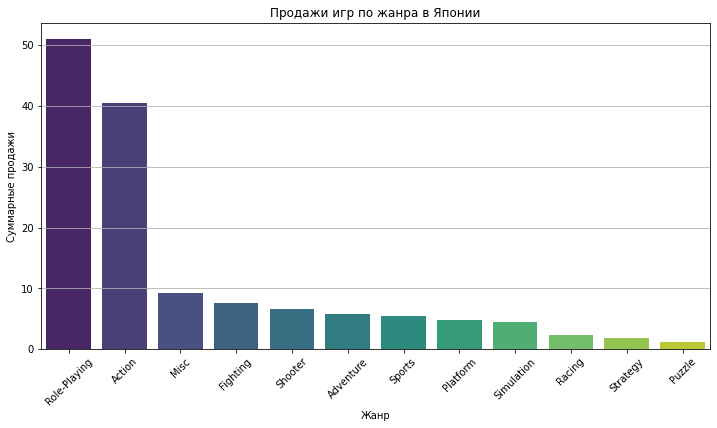

In [1852]:
jp_genre_pivot_table_reset = jp_genre_pivot_table.reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(data=jp_genre_pivot_table_reset, x='genre', y='jp_sales', palette='viridis')

plt.title('Продажи игр по жанра в Японии')
plt.xlabel('Жанр')
plt.ylabel('Суммарные продажи')
plt.xticks(rotation=45) 
plt.grid(axis='y')
plt.show()

Рейтинг жанров:
1. Топ 5 по Северной Америке: Action, Shooter, Sports, Role-Playing и Misc
2. Топ 5 по Европейскому региону: Action, Shooter, Sports, Role-Playing и Racing
3. Топ 5 по Японии: Role-Playing, Action, Misc, Fighting и Shooter

По классификации Кроуфорда miscellaneous game (Misc) - игры в категории skill-and-action. Они не относятся к боевым играм(Combat),играм с выходом из лабиринта(Maze), спортивным играм(Sports), играм на удержание мяча(Paddle) или гонкам(Race). Это новые игры, где проверяется ловкость и реакция игрока другими способами.

Американские и европейские игроки имеют схожите тенденции по жанрам в целом. 
Японские отличаются от них большим вкладом в игры с глубоким смыслом. 
Вне зависимости от региона всегда будут популярны игры экшен, т.к. многие поколения выросли на этом жанре, и шутеры, т.к. это имитация боевых действий.

Найдем влияние рейтинга на каждый регион.

In [1853]:
na_rating_pivot_table = pd.pivot_table(na_actual_data_games_sales, index='rating', values='na_sales',
                                        aggfunc='sum').sort_values('na_sales', ascending=False)
na_rating_pivot_table

,na_sales
rating,
M,165.21
No information,89.42
E,79.05
E10+,54.24
T,49.79


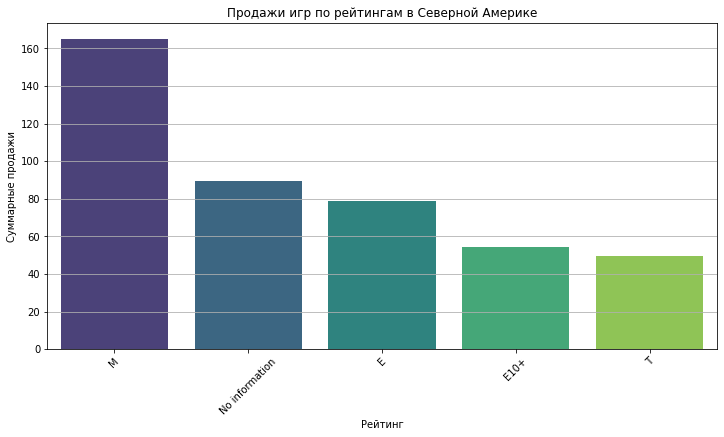

In [1854]:
na_rating_pivot_table_reset = na_rating_pivot_table.reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(data=na_rating_pivot_table_reset, x='rating', y='na_sales', palette='viridis')

plt.title('Продажи игр по рейтингам в Северной Америке')
plt.xlabel('Рейтинг')
plt.ylabel('Суммарные продажи')
plt.xticks(rotation=45) 
plt.grid(axis='y')
plt.show()

In [1855]:
eu_rating_pivot_table = pd.pivot_table(eu_actual_data_games_sales, index='rating', values='eu_sales',
                                        aggfunc='sum').sort_values('eu_sales', ascending=False)
eu_rating_pivot_table

,eu_sales
rating,
M,145.32
E,83.36
No information,78.91
E10+,42.69
T,41.95


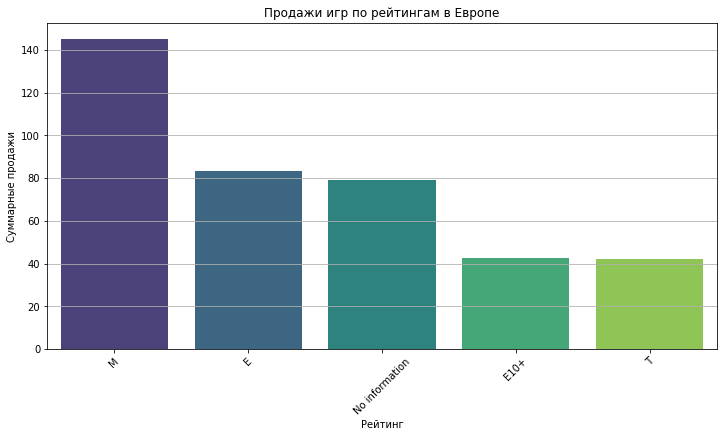

In [1856]:
eu_rating_pivot_table_reset = eu_rating_pivot_table.reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(data=eu_rating_pivot_table_reset, x='rating', y='eu_sales', palette='viridis')

plt.title('Продажи игр по рейтингам в Европе')
plt.xlabel('Рейтинг')
plt.ylabel('Суммарные продажи')
plt.xticks(rotation=45) 
plt.grid(axis='y')
plt.show()

In [1857]:
jp_rating_pivot_table = pd.pivot_table(jp_actual_data_games_sales, index='rating', values='jp_sales',
                                        aggfunc='sum').sort_values('jp_sales', ascending=False)
jp_rating_pivot_table

,jp_sales
rating,
No information,85.05
T,20.59
E,15.14
M,14.11
E10+,5.89


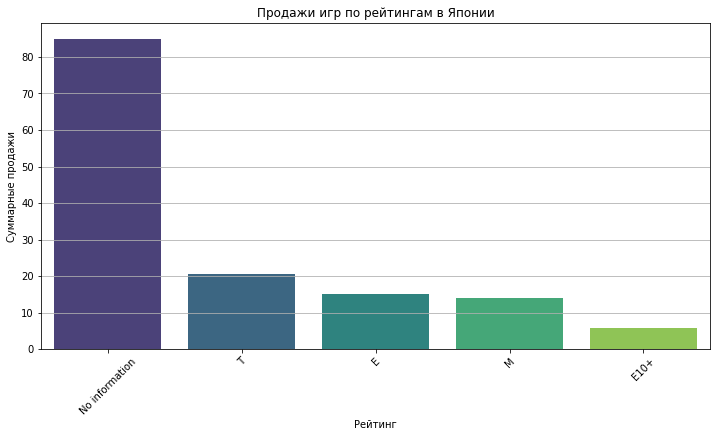

In [1858]:
jp_rating_pivot_table_reset = jp_rating_pivot_table.reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(data=jp_rating_pivot_table_reset, x='rating', y='jp_sales', palette='viridis')

plt.title('Продажи игр по рейтингам в Японии')
plt.xlabel('Рейтинг')
plt.ylabel('Суммарные продажи')
plt.xticks(rotation=45) 
plt.grid(axis='y')
plt.show()

Рейтинг возраста влияет по каждому региону. 

В Америке и Европе схожие ситуации - в первую очередь популярны игры с возрастным рейтингом 17+. Это означает, что эти рынки ориентированы на взрослых пользователей.

В Японии лидириуют игры с возрастным рейтингом 13+. Компании хотят распространить свое влияние на новое поколение.

##### Вывод по составлению портрета пользователя каждого региона

Проведя анализ по регионам можно составить портрет игрока.

Американский игрок - от 17 лет, любит играть или на PS4, или на XOne, любит игры на реакцию и шутеры.
Европейский игрок - от 17 лет, любит играть на PS4, любит игры на реакцию и шутеры.
Японский игрок - от 13 лет, любит играть на переносных платформах 3DS или PSV, любит тратить время на RPG и экшены.

### Шаг 5. Проверка гипотез

Стоит задача проверить две гипотезы:
1. Средние пользовательские рейтинги платформ Xbox One и PC одинаковые;
2. Средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») разные.

Подготовим данные по первой гипотезе. Не будем учитывать игры с пустым рейтингом.

In [1859]:
def stat_info(serie, bins=0):
    serie_description = serie.describe()
    mean = serie_description[1]
    std = serie_description[2]
    d_min = serie_description[3]
    q1 = serie_description[4]
    median = serie_description[5]
    q3 = serie_description[6]
    d_max = serie_description[7]
    left_border = d_min
    right_border = d_max
    if bins == 0:
        bins = right_border - left_border
        if bins>100:
            bins = 100
        elif bins < 1:
            bins = abs(bins*10)+1
        bins = int(bins)
    else:
        bins = bins
    serie.hist(bins=bins, range=(left_border, right_border))
    print(serie_description)
    variance_estimate = np.var(serie, ddof=1)
    standart_dev = np.std(serie, ddof=1)
    print('Среднее значение: {:.2f}'.format(mean))
    print('Дисперсия: {:.2f}'.format(variance_estimate))
    print('Стандартное отклонение: {:.2f}'.format(standart_dev))
    return [mean, variance_estimate, standart_dev]

count    182.000000
mean       6.521429
std        1.380941
min        1.600000
25%        5.800000
50%        6.800000
75%        7.500000
max        9.200000
Name: user_score, dtype: float64
Среднее значение: 6.52
Дисперсия: 1.91
Стандартное отклонение: 1.38


[6.521428579157526, 1.9069968580146104, 1.3809405700516624]

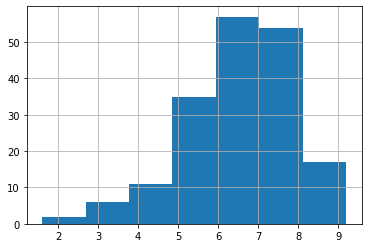

In [1860]:
user_rating_XOne = actual_data_games_sales.query('platform == "XOne"')['user_score'].dropna()
stat_info(user_rating_XOne)

count    155.000000
mean       6.269677
std        1.742381
min        1.400000
25%        5.300000
50%        6.800000
75%        7.600000
max        9.300000
Name: user_score, dtype: float64
Среднее значение: 6.27
Дисперсия: 3.04
Стандартное отклонение: 1.74


[6.269677446734521, 3.0358927793463093, 1.7423813530184227]

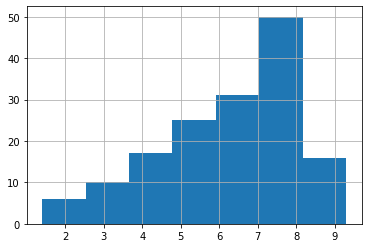

In [1861]:
user_rating_PC = actual_data_games_sales.query('platform == "PC"')['user_score'].dropna()
stat_info(user_rating_PC)

На первый взгляд средние похожи, но вот дисперсия выборок отличается.

Нулевая гипотеза первой гипотезы гласит: "Средние пользовательские рейтинги платформ Xbox One и PC одинаковые".

Альтернативная гипотеза гласит: "Средние пользовательские рейтинги платформ Xbox One и PC различаются".

Для оценки гипотезы будем применять тест Стюдента. Соотвественно, мы можем получить два ответа "Отвергаем нулевую гипотезу" и "Не получилось отвергнуть нулевую гипотезу". 

При получении ответа "Отвергаем нулевую гипотезу" это будет говорить о том, что гипотеза противоречит эмпирическим данным и скорей всего наше предположение неверно. Значит данные различаются.

При получении ответа "Не получилось отвергнуть нулевую гипотезу", это значит что предположение о равенстве среднего рейтинга верно.

In [1862]:
alpha = .01

results = st.ttest_ind(user_rating_XOne, user_rating_PC)

print('p-значение:', results.pvalue)

if (results.pvalue < alpha):
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу")

p-значение: 0.1401266165532671
Не получилось отвергнуть нулевую гипотезу


Рейтинги в целом похожи друг на друга, что и подтверждает нулевая гипотеза.

Подготовим данные для жанров Action и Sports.

count    389.000000
mean       6.837532
std        1.330173
min        2.000000
25%        6.300000
50%        7.100000
75%        7.800000
max        9.100000
Name: user_score, dtype: float64
Среднее значение: 6.84
Дисперсия: 1.77
Стандартное отклонение: 1.33


[6.837532154392155, 1.7693609196980824, 1.3301732667957518]

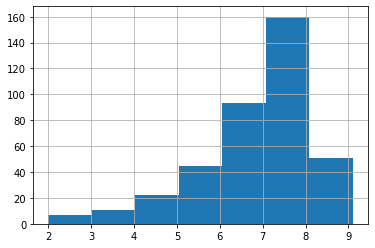

In [1863]:
user_rating_Action = actual_data_games_sales.query('genre == "Action"')['user_score'].dropna()
stat_info(user_rating_Action)

count    160.000000
mean       5.238125
std        1.783427
min        0.200000
25%        4.100000
50%        5.500000
75%        6.500000
max        8.800000
Name: user_score, dtype: float64
Среднее значение: 5.24
Дисперсия: 3.18
Стандартное отклонение: 1.78


[5.238124996516854, 3.1806128043337365, 1.7834272635388684]

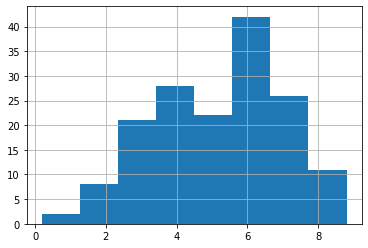

In [1864]:
user_rating_Sports = actual_data_games_sales.query('genre == "Sports"')['user_score'].dropna()
stat_info(user_rating_Sports)

На первый взгляд по статистическим данным все отличается.

Нулевая гипотеза первой гипотезы гласит: "Средние пользовательские рейтинги жанров Action и Sports одинаковые".

Альтернативная гипотеза гласит: "Средние пользовательские рейтинги жанров Action и Sports различаются".

Для оценки гипотезы будем применять тест Стюдента. Соотвественно, мы можем получить два ответа "Отвергаем нулевую гипотезу" и "Не получилось отвергнуть нулевую гипотезу". 

При получении ответа "Отвергаем нулевую гипотезу" это будет говорить о том, что гипотеза противоречит эмпирическим данным и скорей всего наше предположение неверно. Значит данные различаются.

При получении ответа "Не получилось отвергнуть нулевую гипотезу", это значит что предположение о равенстве среднего рейтинга верно.

In [1865]:
alpha = .01

results = st.ttest_ind(user_rating_Action, user_rating_Sports)

print('p-значение:', results.pvalue)

if (results.pvalue < alpha):
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу")

p-значение: 1.0517817316679538e-27
Отвергаем нулевую гипотезу


Тест Стьюдента подтвердил наши догадки о различиях между выбранными жанрами.

##### Вывод по проверке гипотез

Первая и вторая гипотезы подтвердились.

Платформа XOne старается из года в год набирать новых пользователей, чтобы соревноваться не только с PS4, но и с самой распространненной платформой на земле PC. На 2016 год по качеству игр они близки к компьютерным.

Различия между Action и Sports существуют из-за опыта создания игр. Первые экшены появились в 80х годах и из года в год они становятся интересней, так как им есть на что ровняться в прошлом. У спортивных игр в большинстве случаев ограничением в рейтингах стоит симуляция реальных спортивных игр. И любителям этой серии иногда приходиться сталкиваться с непонятными решениями в этих играх.

### Итоговый вывод

В ходе проделанной работы было выполнено:

1. Просмотрена таблица, выявлены аномалии и пропущенные значения.
2. Проведена предобработка таблицы: замена столбцов, заполнение пропусков, удаление дубликатов и т.д.
3. Проведен анализ по данным и подготовлены актуальные данные.
4. Составлены портреты пользователей для купных регионов продаж.
5. Выполнены проверки гипотез.

Продажи компьютерных игр зависят от трех основных составляющих: кто игру создал, на какой платформе она сделана и какого она жанра.

- По первому пунку сейчас популярны компании, которые уже давно разрабатывают игры. Они используют свои любимые жанры и уже накопили аудиторию фанатов, которая обязательно купит их игру.
- Платформа определяет технические возможности разработчиков. Здесь есть прямая зависимость: лучше платформа значит можно сделать игру лучше. Жизненный цикл в 5-12 лет обусловлен скачками в технологиях процессора, оперативной и видеопамяти.
- Жанр - это то, что выбирает игрок. Каждый человек уникален, и не каждому игроку будет по душе одновременно стратегия и шутеры. Соответсвенно студии-разработчики и издатели боряться за целевую аудиторию своего продукта.

Сводный анализ для кампании на 2017 год.

1. Делать ставку на современные платформы. Покупать вышедшие и новые игры на PS4, XOne и 3DS.
2. Выставлять на прилавки популярные жанры - экшен, шутеры, спортивные и ролевые игры.
3. Следить за своей аудиторией. В основом большинство игр рассчитано на игроков, которым 17 лет и старше.
4. Не забывать распространять компьютерные игры и портации игр с популярных платформ на PC. Компьютер еще долго не выйдет из конкуренции за игроков. 